# Actividad 1: Reducción de Dimensionalidades

## 1) Carga de librerías y dataset

Usaremos el dataset **Wine** (178 muestras, 13 atributos fisicoquímicos) incluido en `scikit-learn`. Es numérico y multiclase.


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

In [65]:
# Cargar dataset Wine como DataFrame
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df.rename(columns={"target": "clase"}, inplace=True)

# Separar X (características) e y (etiqueta)
X = df.drop(columns=["clase"]).copy()
y = df["clase"].copy()

print("Dimensiones (filas, columnas):", df.shape)
df.head()


Dimensiones (filas, columnas): (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2) Correlaciones entre variables

Calculamos la matriz de correlación de Pearson y la visualizamos.


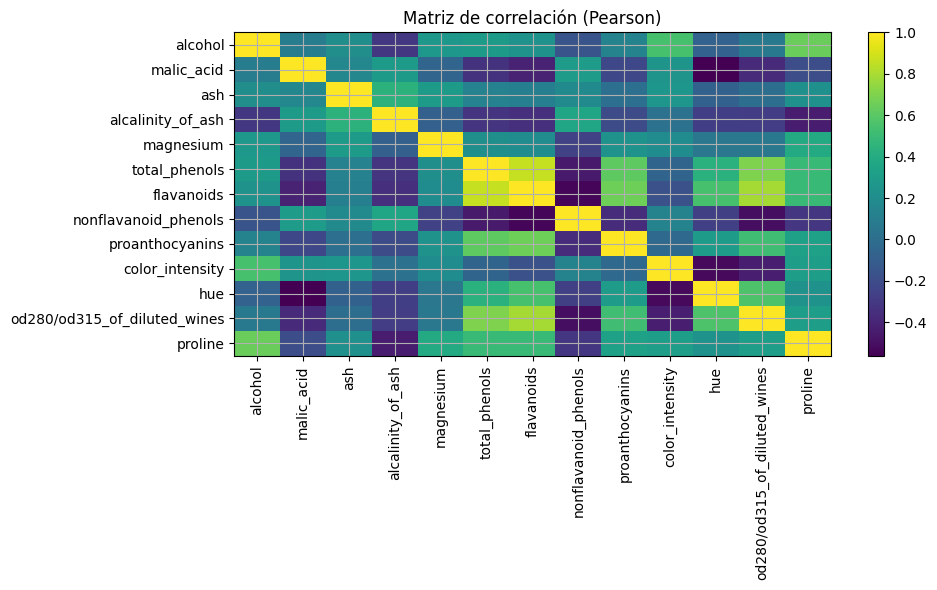

In [66]:
corr = X.corr(method='pearson', numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()


## 3) Escalado de características (StandardScaler)

Estandarizamos las variables a media 0 y desviación estándar 1


In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Verificamos: media ~0, std ~1
display(X_scaled.describe().loc[["mean", "std"]])


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00


## 4) PCA: varianza explicada y proyección 2D

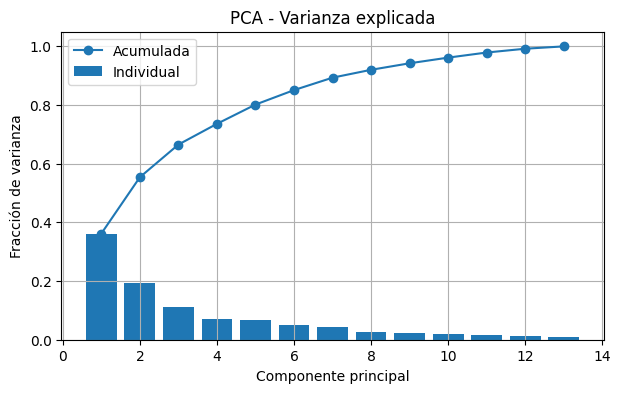

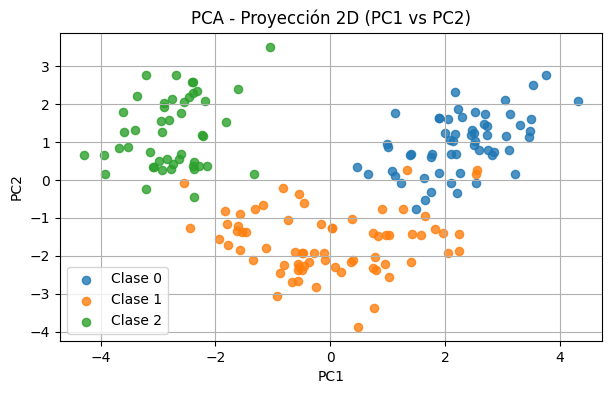

In [62]:
pca = PCA()
pca.fit(X_scaled)

exp_var = pca.explained_variance_ratio_
cum_exp = np.cumsum(exp_var)
k = len(exp_var)

# Varianza explicada
fig, ax = plt.subplots()
ax.bar(range(1, k+1), exp_var, label="Individual")
ax.plot(range(1, k+1), cum_exp, marker="o", label="Acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Fracción de varianza")
ax.set_title("PCA - Varianza explicada")
ax.legend()
plt.show()

# Proyección 2D
Z = pca.transform(X_scaled)
pc1, pc2 = Z[:,0], Z[:,1]

fig, ax = plt.subplots()
for c in np.unique(y):
    sel = y.values == c
    ax.scatter(pc1[sel], pc2[sel], s=35, alpha=0.8, label=f"Clase {c}")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA - Proyección 2D (PC1 vs PC2)")
ax.legend()
plt.show()


## 5) KNN y la Maldición de la Dimensionalidad

El  KNN es muy sensible a la cantidad de dimensiones. En espacios de alta dimensión, los puntos tienden a estar a distancias muy similares entre sí, lo que dificulta la clasificación.

In [63]:
# 1. Dividir datos originales
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 2. KNN con TODAS las dimensiones (13)
knn_full = KNeighborsClassifier(n_neighbors=5)
knn_full.fit(X_train, y_train)
y_pred_full = knn_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)

# 3. KNN con PCA (2 componentes)
# Usamos la proyección Z calculada anteriormente
Z_train, Z_test, y_train_pca, y_test_pca = train_test_split(Z[:, :2], y, test_size=0.3, random_state=42, stratify=y)

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(Z_train, y_train_pca)
y_pred_pca = knn_pca.predict(Z_test)
acc_pca = accuracy_score(y_test_pca, y_pred_pca)

print(f"Accuracy con todas las dimensiones ({X_train.shape[1]}): {acc_full:.4f}")
print(f"Accuracy con PCA ({Z_train.shape[1]} componentes): {acc_pca:.4f}")

Accuracy con todas las dimensiones (13): 0.9444
Accuracy con PCA (2 componentes): 0.9630
